<a href="https://colab.research.google.com/github/Egyy24/Analisis-dan-Prediksi-Harga-Rumah-dengan-Linear-Regression/blob/main/Analisis_dan_Prediksi_Harga_Rumah_dengan_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




```
Qanzul Arays (23523228)
Muhammad Ibnu Rasyid (23523127)
```



# **Import Library dan Load Dataset**
Impor library yang dibutuhkan dalam analisis dan pemodelan data:

*   `pandas` untuk membaca dan mengolah dataset
*   `numpy` untuk operasi numerik
*   `matplotlib` dan `seaborn` untuk visualisasi
*   `sklearn` untuk membuat model machine learning

Selain itu, pada cell ini juga dilakukan:


*   Membaca dataset dari file CSV (`house_prices_dataset.csv`)
*   Menampilkan 5 baris pertama dataset untuk memastikan data berhasil dimuat dengan benar




  





In [ ]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import pandas as pd

data = pd.read_csv('/content/sample_data/house_prices_dataset.csv')

data.head()

,square_feet,num_rooms,age,distance_to_city(km),price
0,2248.357077,3,92,22.997972,200374.090410
1,1930.867849,2,22,13.984254,268784.847337
2,2323.844269,6,33,21.500945,315020.857676
3,2761.514928,3,63,10.343638,355111.468459
4,1882.923313,7,54,25.485200,234197.123903


# Informasi Dataset dan Fitur
Link Dataset: [House Price Prediction Dataset](https://www.kaggle.com/datasets/muhamedumarjamil/house-price-prediction-dataset)



Informasi umum dari dataset, meliputi:


*   Struktur data seperti jumlah baris, jumlah kolom, dan tipe data tiap kolom menggunakan `data.info()`
*   Daftar nama seluruh fitur/kolom dalam dataset menggunakan `data.columns.tolist()`

**Jumlah Data**: Dataset ini berisi 10.000 entri (baris).
*   **Fitur**: Fitur-fitur yang tersedia adalah:
    *   `square_feet`: Luas persegi rumah.
    *   `num_rooms`: Jumlah kamar.
    *   `age`: Usia rumah.
    *   `distance_to_city(km)`: Jarak rumah ke kota dalam kilometer.
*   **Variabel Target**: Variabel target yang ingin diprediksi adalah `price` (harga rumah).



In [ ]:
print('Informasi Dataset:')
data.info()
print('\nFitur dalam Dataset:')
print(data.columns.tolist())

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   square_feet           10000 non-null  float64
 1   num_rooms             10000 non-null  int64  
 2   age                   10000 non-null  int64  
 3   distance_to_city(km)  10000 non-null  float64
 4   price                 10000 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 390.8 KB

Fitur dalam Dataset:
['square_feet', 'num_rooms', 'age', 'distance_to_city(km)', 'price']


# Visualisasi Hubungan Luas Rumah dan Harga
Visualisasi berupa scatter plot yang menunjukkan hubungan antara:


*   `square_feet` (luas rumah) sebagai sumbu X
*   `price` (harga rumah) sebagai sumbu Y

Visualisasi ini bertujuan untuk melihat apakah terdapat hubungan atau pola antara luas rumah dan harga.

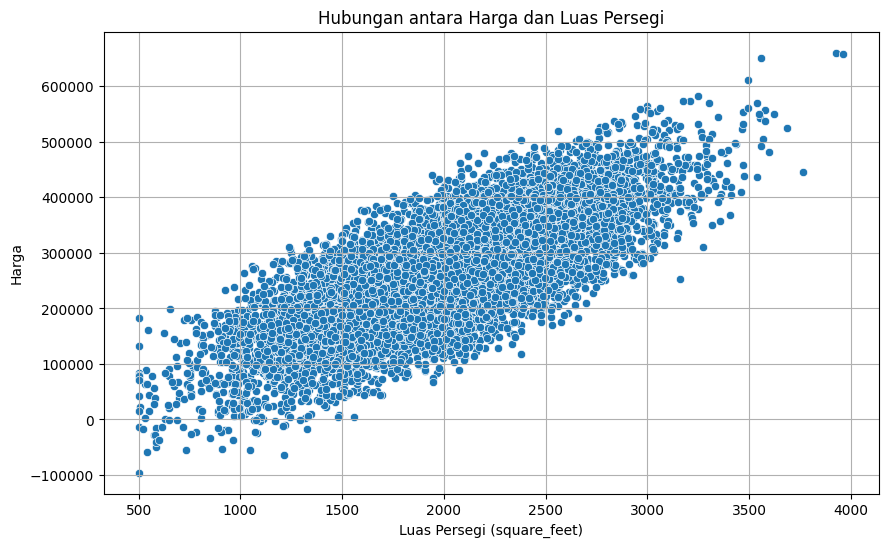

In [ ]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='square_feet', y='price', data=data)
plt.title('Hubungan antara Harga dan Luas Persegi')
plt.xlabel('Luas Persegi (square_feet)')
plt.ylabel('Harga')
plt.grid(True)
plt.show()

# Pembagian Data Training dan Testing

menyiapkan data sebelum proses modeling dengan cara:


*   Memisahkan variabel:
    *   `X` = fitur (luas rumah /`square_feet`)
    *   `y` = target (harga rumah /`price`)
*  Membagi dataset menjadi:
    *   **Data training (80%)** digunakan untuk melatih model
    *   **Data testing (20%)** digunakan untuk menguji performa model





In [ ]:
X = data[['square_feet']]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Ukuran data training X: {X_train.shape}')
print(f'Ukuran data testing X: {X_test.shape}')
print(f'Ukuran data training y: {y_train.shape}')
print(f'Ukuran data testing y: {y_test.shape}')

Ukuran data training X: (8000, 1)
Ukuran data testing X: (2000, 1)
Ukuran data training y: (8000,)
Ukuran data testing y: (2000,)


# Training Model Linear Regression
Membuat model Linear Regression

*  `model = LinearRegression()`

Melatih model menggunakan data training

*   `model.fit(X_train, y_train)`

Menampilkan parameter model




*   `print(f'Intercept (bias): {model.intercept_}')`
*   `print(f'Koefisien (square_feet): {model.coef_[0]}')`



In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

print(f'Intercept: {model.intercept_}')
print(f'Koefisien (square_feet): {model.coef_[0]}')

Intercept: -33350.87046710949
Koefisien (square_feet): 148.30543270274777


# Prediksi Menggunakan Model
Melakukan prediksi pada data testing

*   `y_pred = model.predict(X_test)`

Menampilkan parameter model

*   `print(f'Intercept (bias): {model.intercept_}')`
*   `print(f'Koefisien (square_feet): {model.coef_[0]}')`



In [ ]:
y_pred = model.predict(X_test)

print(f'Intercept: {model.intercept_}')
print(f'Koefisien (square_feet): {model.coef_[0]}')

Intercept: -33350.87046710949
Koefisien (square_feet): 148.30543270274777


# Evaluasi Model (Mean Squared Error)

Menghitung Mean Squared Error (MSE)

*   `mse = mean_squared_error(y_test, y_pred)`


In [ ]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error (MSE): {mse}')

Mean Squared Error (MSE): 4104994493.189088


# Visualisasi Regresi Linear
Grafik hasil regresi linear menggunakan Matplotlib dan Seaborn.

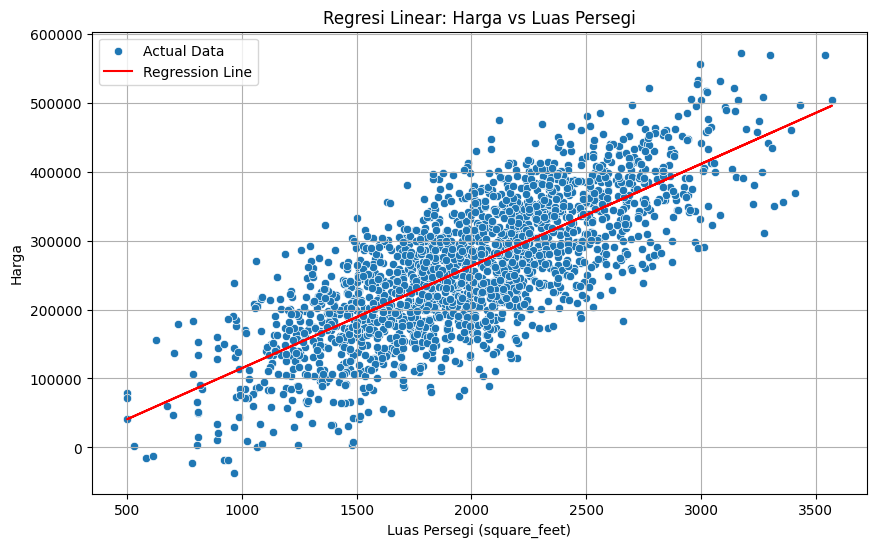

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_test['square_feet'], y=y_test, label='Actual Data')
plt.plot(X_test, y_pred, color='red', label='Regression Line')
plt.title('Regresi Linear: Harga vs Luas Persegi')
plt.xlabel('Luas Persegi (square_feet)')
plt.ylabel('Harga')
plt.legend()
plt.grid(True)
plt.show()

# Analisis dan Kesimpulan

*   Intercept (`-33350.87`), perkiraan harga rumah ketika `square_feet` (luas persegi) adalah nol. Nilai negatif di sini tidak perlu diartikan secara harfiah (tidak ada rumah berluas 0), tapi hanya bagian dari perhitungan matematis agar garis regresi bisa pas dengan seluruh data.
*   Koefisien (`148.31`), ini adalah slope dari garis regresi. Artinya, untuk setiap peningkatan satu unit `square_feet`, harga rumah diperkirakan akan meningkat sebesar $148.31.


*   Mean Squared Error (MSE) (`4,104,994,493.19`), angka MSE yang besar ini menunjukkan bahwa terdapat perbedaan yang besar antara prediksi model dan harga rumah aktual. Mengingat harga rumah bisa mencapai ratusan ribu, MSE yang besar ini berarti model tunggal dengan hanya satu fitur (`square_feet`) mungkin belum cukup akurat untuk memprediksi harga dengan baik. Visualisasi scatter plot dengan garis regresi juga menunjukkan ada banyak titik data yang jauh dari garis, artinya ada error yang besar.
*   Berdasarkan MSE yang tinggi dan penggunaan hanya satu fitur (`square_feet`), ada kemungkinan kuat bahwa model ini underfitting. Model terlalu sederhana dan tidak mampu menangkap semua pola dalam data harga rumah.







